Polynomial Regression

In [167]:
import pandas as pd

In [168]:
df=pd.read_csv("Ice_cream selling data.csv")

In [169]:
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [170]:
x=df[['Temperature (°C)']]


In [171]:
x

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [172]:
y=df['Ice Cream Sales (units)']

In [173]:
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [174]:
from sklearn.linear_model import LinearRegression

In [175]:
from sklearn.model_selection import train_test_split


In [176]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [177]:
x_train.shape

(39, 1)

In [178]:
x_test.shape

(10, 1)

In [179]:
model=LinearRegression()

In [180]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [181]:
model.score(x_test,y_test)

-0.31427767797624884

In [182]:
import matplotlib.pyplot as plt

In [183]:
y_pred=model.predict(x_train)

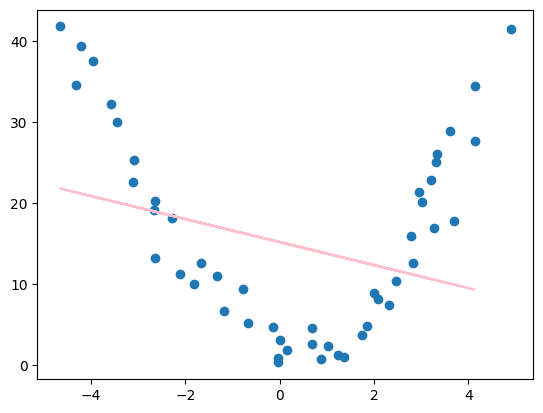

In [ ]:
plt.scatter(df["Temperature (°C)"],df['Ice Cream Sales (units)'])
plt.plot(x_train['Temperature (°C)'],y_pred,color="pink")

In [185]:
from sklearn.preprocessing import PolynomialFeatures

In [186]:
pf=PolynomialFeatures(degree=2)

In [187]:
x_train2=pf.fit_transform(x_train)

In [188]:
x_test2=pf.transform(x_test)

In [189]:
x_train2.shape

(39, 3)

In [190]:
reg=LinearRegression()

In [191]:
reg.fit(x_train2,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [192]:
reg.score(x_test2,y_test)

0.9470446802424923

In [193]:
y_pred=reg.predict(x_train2)

In [194]:
y_pred.shape

(39,)

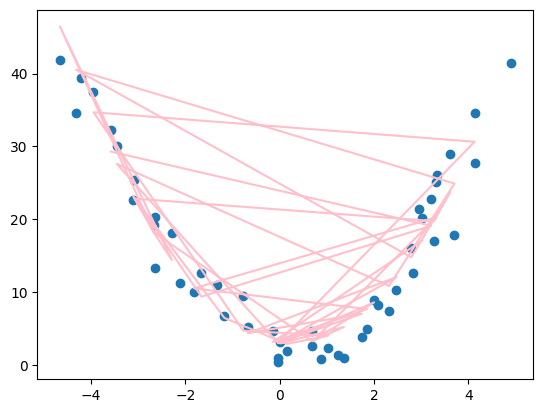

In [196]:
plt.scatter(df[["Temperature (°C)"]],df['Ice Cream Sales (units)'])
plt.plot(x_train['Temperature (°C)'],y_pred,color="pink")


In [198]:
import numpy as np

In [199]:
x_curve=np.linspace(x.min(),x.max(),200)

In [200]:
x_curve

array([[-4.66226268e+00],
       [-4.61421597e+00],
       [-4.56616927e+00],
       [-4.51812256e+00],
       [-4.47007586e+00],
       [-4.42202915e+00],
       [-4.37398245e+00],
       [-4.32593575e+00],
       [-4.27788904e+00],
       [-4.22984234e+00],
       [-4.18179563e+00],
       [-4.13374893e+00],
       [-4.08570222e+00],
       [-4.03765552e+00],
       [-3.98960881e+00],
       [-3.94156211e+00],
       [-3.89351541e+00],
       [-3.84546870e+00],
       [-3.79742200e+00],
       [-3.74937529e+00],
       [-3.70132859e+00],
       [-3.65328188e+00],
       [-3.60523518e+00],
       [-3.55718847e+00],
       [-3.50914177e+00],
       [-3.46109507e+00],
       [-3.41304836e+00],
       [-3.36500166e+00],
       [-3.31695495e+00],
       [-3.26890825e+00],
       [-3.22086154e+00],
       [-3.17281484e+00],
       [-3.12476813e+00],
       [-3.07672143e+00],
       [-3.02867473e+00],
       [-2.98062802e+00],
       [-2.93258132e+00],
       [-2.88453461e+00],
       [-2.8

In [201]:
x_curve2=pf.transform(x_curve)

c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [202]:
x_curve2

array([[ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00, -4.61421597e+00,  2.12909890e+01],
       [ 1.00000000e+00, -4.56616927e+00,  2.08499018e+01],
       [ 1.00000000e+00, -4.51812256e+00,  2.04134315e+01],
       [ 1.00000000e+00, -4.47007586e+00,  1.99815782e+01],
       [ 1.00000000e+00, -4.42202915e+00,  1.95543418e+01],
       [ 1.00000000e+00, -4.37398245e+00,  1.91317225e+01],
       [ 1.00000000e+00, -4.32593575e+00,  1.87137201e+01],
       [ 1.00000000e+00, -4.27788904e+00,  1.83003347e+01],
       [ 1.00000000e+00, -4.22984234e+00,  1.78915662e+01],
       [ 1.00000000e+00, -4.18179563e+00,  1.74874147e+01],
       [ 1.00000000e+00, -4.13374893e+00,  1.70878802e+01],
       [ 1.00000000e+00, -4.08570222e+00,  1.66929627e+01],
       [ 1.00000000e+00, -4.03765552e+00,  1.63026621e+01],
       [ 1.00000000e+00, -3.98960881e+00,  1.59169785e+01],
       [ 1.00000000e+00, -3.94156211e+00,  1.55359119e+01],
       [ 1.00000000e+00, -3.89351541e+00

In [203]:
y_pred2=reg.predict(x_curve2)

In [204]:
y_pred2

array([46.47637861, 45.62363353, 44.77930803, 43.94340213, 43.11591582,
       42.29684909, 41.48620196, 40.68397442, 39.89016647, 39.10477811,
       38.32780934, 37.55926016, 36.79913057, 36.04742057, 35.30413016,
       34.56925935, 33.84280812, 33.12477648, 32.41516444, 31.71397198,
       31.02119912, 30.33684584, 29.66091216, 28.99339807, 28.33430357,
       27.68362865, 27.04137333, 26.4075376 , 25.78212146, 25.16512491,
       24.55654795, 23.95639058, 23.36465281, 22.78133462, 22.20643602,
       21.63995702, 21.0818976 , 20.53225777, 19.99103754, 19.45823689,
       18.93385584, 18.41789438, 17.91035251, 17.41123022, 16.92052753,
       16.43824443, 15.96438092, 15.498937  , 15.04191267, 14.59330793,
       14.15312278, 13.72135723, 13.29801126, 12.88308488, 12.4765781 ,
       12.0784909 , 11.6888233 , 11.30757528, 10.93474686, 10.57033802,
       10.21434878,  9.86677913,  9.52762907,  9.1968986 ,  8.87458772,
        8.56069643,  8.25522473,  7.95817262,  7.6695401 ,  7.38

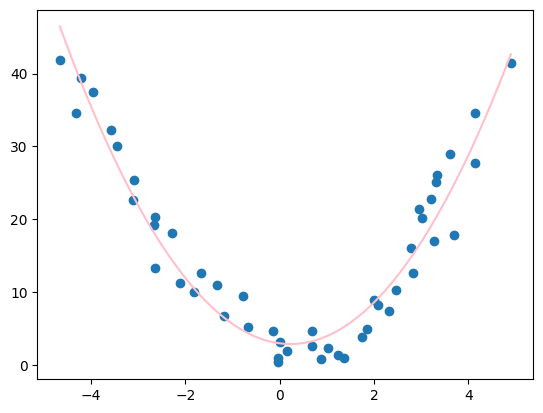

In [208]:
plt.scatter(df[["Temperature (°C)"]],df['Ice Cream Sales (units)'])
plt.plot(x_curve[:,0],y_pred2,color="pink")